<a href="https://colab.research.google.com/github/krlpopiel/SI_lab/blob/develop/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [12]:
observations = 100000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(100000, 2)


In [13]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(100000, 1)


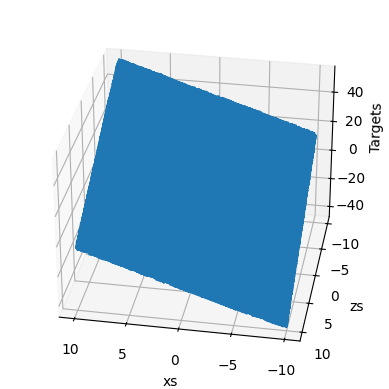

In [14]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [15]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[0.0544616]
 [0.0059953]] [-0.09591269]


In [16]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = targets - outputs

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights + eta * np.dot(inputs.T, deltas_scaled)
  biases = biases + eta * np.sum(deltas_scaled)

227.18950640517954
36.3695654719695
14.773353142723769
11.959082389362909
11.24416830453308
10.77801450892671
10.354767958773735
9.950993096135536
9.563508208895849
9.191400864343088
8.834032466961458
8.49081607346833
8.161190907412735
7.844618723136339
7.540582625193512
7.248586190907234
6.968152656110381
6.698824136285842
6.440160878899004
6.191740545376301
5.953157521521301
5.724022255238474
5.50396062048272
5.292613306396192
5.0896352306349915
4.8946949759277425
4.7074742489461965
4.527667360604242
4.354980726936792
4.189132389743597
4.029851556215292
3.876878156790021
3.7299624205186857
3.58886446724549
3.453353915937927
3.323209508526685
3.1982187486412714
3.0781775546515266
2.9628899264485016
2.852167625420617
2.7458298671026102
2.6437030259954075
2.545620352074965
2.4514216985272097
2.3609532602645342
2.274067322796874
2.1906220210473886
2.11048110771887
2.0335137308327433
1.959594220077394
1.8886018816169783
1.8204208010257017
1.7549396540257862
1.6920515247201182
1.6316537310

In [7]:
print(weights, biases)

[[ 2.00008171]
 [-3.00009952]] [4.34907017]


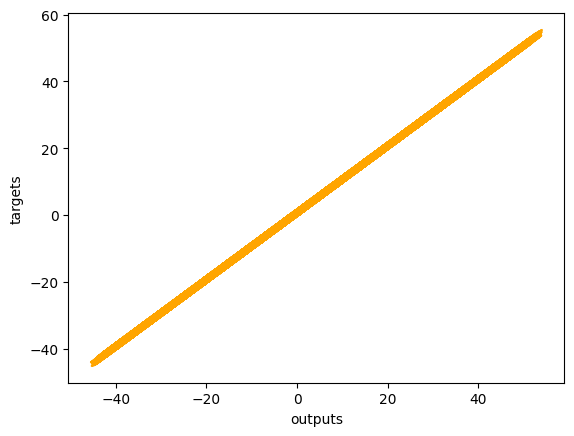

In [17]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()